# Phase 4: Predictive Modelling

### Imports

In [0]:
import pandas as pd
import numpy as np
import mlflow
from pmdarima import auto_arima
from pmdarima.arima import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates
from prophet import Prophet
from xgboost import XGBRegressor

### MLFlow Set Up

In [0]:
mlflow.set_experiment("/Shared/nyc-taxi-demand-forecasting")

<Experiment: artifact_location='dbfs:/databricks/mlflow-tracking/4318419190935406', creation_time=1786022956204, experiment_id='4318419190935406', last_update_time=1786472858162, lifecycle_stage='active', name='/Shared/nyc-taxi-demand-forecasting', tags={'mlflow.experiment.sourceName': '/Shared/nyc-taxi-demand-forecasting',
 'mlflow.experimentKind': 'custom_model_development',
 'mlflow.experimentType': 'MLFLOW_EXPERIMENT',
 'mlflow.ownerEmail': 'domwatkinssmith@gmail.com',
 'mlflow.ownerId': '71869950304311'}>

### Backtesting Windows Dict

In [0]:
BACKTEST_WINDOWS = [
    {"label": "january_weekday", "date": "2025-01-14"},  # Tue -- post-holiday baseline, cold weather
    {"label": "january_weekend", "date": "2025-01-18"},  # Sat -- low-season weekend
    {"label": "july_weekday",    "date": "2025-07-15"},  # Tue -- summer peak, tourist season
    {"label": "july_weekend",    "date": "2025-07-19"},  # Sat -- summer weekend
    {"label": "thanksgiving",    "date": "2025-11-27"},  # Thu -- Thanksgiving 2025
    {"label": "new_years_eve",   "date": "2025-12-31"},  # Wed -- holiday + late-night spike
]

### Pull Data from Features Table -> Create Dataframe

In [0]:
# delta table -> pandas dataframe
features_df = spark.sql("SELECT * FROM features").toPandas()
features_df = features_df.set_index('hour')
features_df = features_df.sort_index()
features_df

,green,hvfhv,yellow,total_trips,hour_of_day,day_of_week,month,is_weekend,is_holiday,lag_1h,lag_2h,lag_3h,lag_4h,lag_5h,lag_6h,lag_7h,lag_8h,lag_9h,lag_10h,lag_11h,lag_12h,lag_13h,lag_14h,lag_15h,lag_16h,lag_17h,lag_18h,lag_19h,lag_20h,lag_21h,lag_22h,lag_23h,lag_24h,rolling_mean_24h,rolling_mean_168h
hour,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2019-02-01 00:00:00,410.0,23513.0,6994.0,30917.0,0,4,2,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-02-01 01:00:00,261.0,13638.0,4018.0,17917.0,1,4,2,False,False,30917.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-02-01 02:00:00,155.0,8765.0,2413.0,11333.0,2,4,2,False,False,17917.0,30917.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-02-01 03:00:00,125.0,6668.0,1684.0,8477.0,3,4,2,False,False,11333.0,17917.0,30917.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-02-01 04:00:00,133.0,7379.0,1654.0,9166.0,4,4,2,False,False,8477.0,11333.0,17917.0,30917.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 19:00:00,85.0,58324.0,8054.0,66463.0,19,2,12,False,False,55880.0,49996.0,43796.0,41755.0,39475.0,36622.0,34283.0,32474.0,31843.0,31045.0,29988.0,22839.0,16812.0,10892.0,9181.0,8552.0,11352.0,16468.0,25572.0,32346.0,35674.0,36634.0,37877.0,42789.0,30589.375000,27686.059524
2025-12-31 20:00:00,79.0,64697.0,8038.0,72814.0,20,2,12,False,False,66463.0,55880.0,49996.0,43796.0,41755.0,39475.0,36622.0,34283.0,32474.0,31843.0,31045.0,29988.0,22839.0,16812.0,10892.0,9181.0,8552.0,11352.0,16468.0,25572.0,32346.0,35674.0,36634.0,37877.0,31575.791667,27792.505952
2025-12-31 21:00:00,78.0,65380.0,7866.0,73324.0,21,2,12,False,False,72814.0,66463.0,55880.0,49996.0,43796.0,41755.0,39475.0,36622.0,34283.0,32474.0,31843.0,31045.0,29988.0,22839.0,16812.0,10892.0,9181.0,8552.0,11352.0,16468.0,25572.0,32346.0,35674.0,36634.0,33031.500000,27956.791667


### Stationarity Check: Variance Stability

ARIMA/SARIMA assume the series is stationary in both mean and variance.
Differencing (`d`/`D`, chosen during model fitting) handles the mean.
This section checks the other half: whether variance is roughly constant
across the target's daily cycle, before any model is fit.

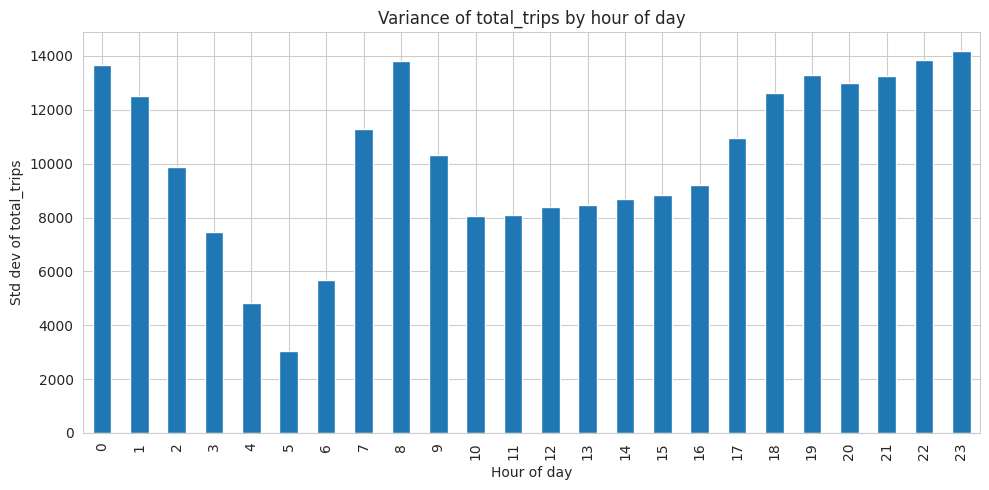

In [0]:
# Check whether variance is constant across hours (stationarity assumption) 
# if variance scales with demand level, a log transform is needed before fitting

# group features_df by hour, take std of total_trips and plot it
# group together every hour in a day, find how spread out are those values around their own average
hourly_std = features_df.groupby(features_df.index.hour)["total_trips"].std()

plt.figure(figsize=(10, 5))
hourly_std.plot(kind="bar")
plt.xlabel("Hour of day")
plt.ylabel("Std dev of total_trips")
plt.title("Variance of total_trips by hour of day")
plt.tight_layout()
plt.show()

**Finding:** variance is not stable across hours. Lowest at 5am (3k std,
matching the demand trough), highest at 8am, 11pm, and midnight (13.5k std,
matching the morning-rush and late-night demand peaks from `02_explore`
Chart 4). Variance scales with the level; classic multiplicative
heteroscedasticity, not noise. `total_trips` will be log-transformed before
fitting, forecasts exponentiated back for evaluation.

## Model 1: ARIMA (baseline, no seasonality)

ARIMA (AutoRegressive Integrated Moving Average) forecasts a value from three components:

- **AR (p)**: how many past values of the series feed into predicting the next one.
  `p=2` means the next value depends partly on the value 1 hour ago and 2 hours ago.
  This captures momentum, if trips have been climbing, the model expects that to continue.

- **I (d)**: how many times the series is differenced (each value replaced by the change
  from the previous one) before fitting. `d=1` means the model is really predicting the
  hour-over-hour change, not the raw trip count. This is needed because AR and MA both
  assume a stationary series (stable mean/variance), and the raw series has a strong trend
  (COVID crash, HVFHV's multi-year growth) that would otherwise throw them off. 

- **MA (q)**: models the current value as a weighted sum of the current and past `q`
  forecast errors (the "moving average" is over the error terms). The weights are chosen by maximum
  likelihood during fitting. If the model overshot last
  hour, `q` lets that error feed into and correct this hour's forecast, catching
  short-term shocks that AR's momentum term alone would miss.

This first pass is deliberately plain ARIMA, no seasonal terms. `auto_arima` searches
`(p, d, q)` combinations and picks the one with the best AIC score.

NYC taxi demand has strong 24h and weekly cycles (see `02_explore`, Charts 4 and 5),
which plain ARIMA has no mechanism to capture. This run is expected to underperform
on that basis, and is used as a deliberate before/after baseline against SARIMA
(next section), which adds seasonal `(P, D, Q, m)` terms

Variance Stabilization: Log Transform

The Stationarity Check earlier in this notebook found that variance in
`total_trips` scales with the demand level, the quietest hour (5am) swings
by the least in absolute terms, the busiest hours (8am, 11pm, midnight)
swing by the most. ARIMA assumes constant variance as well as a stable
mean, so alongside this run, a second version fits on `log(total_trips)`
instead of the raw counts, with forecasts exponentiated back (`np.exp()`)
before evaluation.

Why this works: log compresses large values proportionally more than small
ones, a jump from 10k to 20k trips (a doubling) becomes the same fixed step
in log-space as a jump from 5k to 10k (also a doubling). Since demand swings
by a percentage of its current level rather than a fixed absolute amount,
log-transforming turns those proportional swings into roughly equal-sized
ones, stabilizing the variance the raw series didn't have.

Logged separately to MLflow (`transform=log` param, `arima_log_` run
prefix) so it can be compared directly against the untransformed baseline
above.

Parameter Rundown

- seasonal=False: keeps it "plain" ARIMA rather than SARIMA. No seasonal (P,D,Q,m) search at all, so it genuinely cannot see the 24h cycle even if it wanted to.
- stepwise=True: uses a smart search (Hyndman-Khandakar algorithm) instead of brute-forcing every (p,d,q) combination. Much faster, still lands on a good AIC.
- suppress_warnings=True: some candidate orders throw convergence warnings during the search. This just stops them spamming the output.
- trace=True: prints each candidate order it tries and its AIC, so we can see the search happening rather than a black box.

Evaluation Metrics

- MAE: average absolute miss, in trips. Straightforward to read, "on average we're off by X trips an hour."
- RMSE: same idea but squares the errors before averaging, so a few big misses (like the model going flat through what should be evening rush) drag it up more than MAE would show. RMSE noticeably higher than MAE is itself a signal that some hours are much worse than others, not evenly bad.
- MAPE: the error as a percentage of the actual value, rather than raw trips. This is the one that matters most once we're comparing across windows, a 2,000-trip miss is nothing on New Year's Eve but huge on a quiet Tuesday, MAPE puts every window on the same scale so the 6-window comparison is fair.

### Helper: `get_window_split()` (features_df -> train/test split)

In [0]:
def get_window_split(df, window_date):
    window_start = pd.Timestamp(window_date)
    window_end = window_start + pd.Timedelta(hours=24)
    train = df[df.index < window_start]
    test = df[(df.index >= window_start) & (df.index < window_end)]
    return train, test

### ARIMA Full Run Loop 

In [0]:
RUN_ARIMA_BACKTEST = False  # flip to True to run the log-transformed ARIMA backtest

if RUN_ARIMA_BACKTEST:
    #  main loop - loop through the windows
    for window in BACKTEST_WINDOWS:
        window_date = window['date']  # pull the date out, give it its own name
        train, test = get_window_split(features_df, window_date)  # then call the function with it
        train_y = train["total_trips"] # pull total_trips col
        test_y = test["total_trips"]

        # log-transform to stabilize variance before fitting
        train_y_log = np.log(train_y)  

        # train the model
        arima_model = auto_arima(
            train_y_log,
            seasonal=False,
            stepwise=True,
            suppress_warnings=True,
            trace=False,
        )
        
        # make the forecast
        forecast = np.exp(arima_model.predict(n_periods=24))

        # calculate metrics
        mae = mean_absolute_error(test_y, forecast)
        rmse = np.sqrt(mean_squared_error(test_y, forecast))
        mape = (np.abs((test_y - forecast) / test_y)).mean() * 100

        # save to mlflow
        with    mlflow.start_run(run_name=f"arima_log_{window['label']}"):

                # settings/params
                mlflow.log_param("model_type", "ARIMA")
                mlflow.log_param("transform", "log")
                mlflow.log_param("window", window["label"])
                mlflow.log_param("window_date", window_date)
                mlflow.log_param("order", arima_model.order)

                # metrics
                mlflow.log_metric("mae", mae)
                mlflow.log_metric("rmse", rmse)
                mlflow.log_metric("mape", mape)

                # dataframe of actual vs forecast
                mlflow.log_table(
                    data=pd.DataFrame({"actual": test_y, "forecast": forecast}).reset_index(),
                    artifact_file="forecast.json"
                )
    

In [0]:
arima_runs = mlflow.search_runs(
    experiment_names=["/Shared/nyc-taxi-demand-forecasting"],
    filter_string="params.model_type = 'ARIMA'",
    order_by=["start_time DESC"],
)[["params.window", "params.transform", "metrics.mape"]]

arima_runs.columns = ["window", "transform", "mape"]
arima_runs["transform"] = arima_runs["transform"].fillna("raw")  # early runs predate the transform param
arima_summary = arima_runs.pivot(index="window", columns="transform", values="mape")
arima_summary = arima_summary[["raw", "log"]]
arima_summary

transform,raw,log
window,,
january_weekday,69.506042,61.882353
january_weekend,63.971510,49.150552
july_weekday,64.501136,59.379495
july_weekend,51.862016,35.866041
new_years_eve,64.888471,55.224844
thanksgiving,51.599527,49.499834


## Model 2: SARIMA (seasonal, 24h window)

Same as the ARIMA baseline above, but with seasonality turned on. Rather than searching for (p, d, q) and seasonal (P, D, Q, m) together with auto_arima, this uses a fixed order, (1, 1, 1) with seasonal (1, 1, 1, 24). The seasonal search repeatedly crashed with an out of memory error, even at 32GB, isolated to the search process itself rather than to any single fit. Fixing the order sidesteps the search entirely, a manual choice rather than a data driven one, but m=24 still gives the model the daily cycle mechanism plain ARIMA lacks.

The same log transform used for ARIMA is reused here, fit on log(total_trips) and exponentiated back before scoring. 

### SARIMA Full Run Loop

In [0]:
# same as arima run above, but for SARIMA
# naming and m are the only differences

RUN_SARIMA_BACKTEST = False  # flip to False once run and logged to MLflow

if RUN_SARIMA_BACKTEST:
    for window in BACKTEST_WINDOWS:
        window_date = window['date']
        train, test = get_window_split(features_df, window_date)
        train_y = train["total_trips"]
        test_y = test["total_trips"]

        # log-transform to stabilize variance before fitting
        train_y_log = np.log(train_y) 

        sarima_model = ARIMA(
            order=(1, 1, 1),
            seasonal_order=(1, 1, 1, 24),
            suppress_warnings=True,
        )
        sarima_model.fit(train_y_log)

        sarima_forecast = np.exp(sarima_model.predict(n_periods=24))

        mae = mean_absolute_error(test_y, sarima_forecast)
        rmse = np.sqrt(mean_squared_error(test_y, sarima_forecast))
        mape = (np.abs((test_y - sarima_forecast) / test_y)).mean() * 100

        with    mlflow.start_run(run_name=f"sarima_log_{window['label']}"):

                mlflow.log_param("model_type", "SARIMA")
                mlflow.log_param("transform", "log")
                mlflow.log_param("window", window["label"])
                mlflow.log_param("window_date", window_date)
                mlflow.log_param("order", sarima_model.order)
                mlflow.log_param("seasonal_order", sarima_model.seasonal_order)

                mlflow.log_metric("mae", mae)
                mlflow.log_metric("rmse", rmse)
                mlflow.log_metric("mape", mape)

                mlflow.log_table(
                    data=pd.DataFrame({"actual": test_y, "forecast": sarima_forecast}).reset_index(),
                    artifact_file="forecast.json"
                )

In [0]:
sarima_runs = mlflow.search_runs(
    experiment_names=["/Shared/nyc-taxi-demand-forecasting"],
    filter_string="params.model_type = 'SARIMA'",
    order_by=["start_time DESC"],
)[["params.window", "params.transform", "metrics.mape"]]

sarima_runs.columns = ["window", "transform", "mape"]
sarima_runs["transform"] = sarima_runs["transform"].fillna("raw") # earlier runs didn't have transform param set
sarima_summary = sarima_runs.pivot(index="window", columns="transform", values="mape")
sarima_summary = sarima_summary[["raw", "log"]]
sarima_summary

transform,raw,log
window,,
january_weekday,55.868145,33.947362
january_weekend,48.788097,39.552912
july_weekday,47.103071,27.649392
july_weekend,39.060202,34.133290
new_years_eve,13.377900,15.132590
thanksgiving,29.223527,29.789743


## Model 3: PROPHET 

Prophet decomposes the series into additive components rather than modeling it as an autoregressive process like ARIMA/SARIMA:

y(t) = trend(t) + seasonality(t) + holidays(t) + error

- Trend: a piecewise linear curve (a trend line made of several straight segments joined end to end, each allowed its own slope), with changepoints chosen automatically. Prophet's answer to ARIMA's differencing, but explicit and inspectable rather than folded into d.
- Seasonality: daily, weekly, and yearly cycles, each modeled as a Fourier series (a sum of sine/cosine waves), rather than a single seasonal order like SARIMA's m=24. Training data spans 2019-2024, several years, so yearly seasonality is well fit. It just plays a smaller role inside a 24-hour backtest window than daily/weekly seasonality do: each window is one specific day of the year, so the yearly term mostly contributes a fixed offset for that day (high season vs low season) rather than shaping the hour-to-hour curve, which comes from the daily and weekly terms instead.
- Holidays: specific dates get their own additive effect, learned from the data around them. Directly relevant to two of the six backtest windows, New Year's Eve and Thanksgiving, the exact days where the SARIMA log transform made things worse.

Input format: Prophet expects a dataframe with exactly two columns, ds (timestamp) and y (the target), rather than a plain indexed series like the ARIMA/SARIMA loops used.

Four variants, tested the same way the log transform was tested for ARIMA and SARIMA:
- 3A Raw: untransformed target, default additive seasonality, no holidays.
- 3B Holidays: same as 3A, but with the holidays_df table passed in (Thanksgiving and New Year's Eve dates, 2019-2025), turning on the holidays(t) term in the decomposition above.
- 3C Log Transform: fit on log(total_trips), exponentiated back before scoring, same pattern as ARIMA/SARIMA.
- 3D Multiplicative: untransformed target, seasonality_mode='multiplicative'. Prophet's own built in mechanism for the same heteroscedasticity problem the log transform addresses manually. Not the same fix: multiplicative mode only scales the seasonal and holiday components with the trend level, the trend itself stays on the raw scale, so it is not guaranteed to land on the same answer as the log transform.

### 3A: Raw
(raw target, additive seasonality)

In [0]:
RUN_PROPHET_RAW_BACKTEST = False  # flip to True to run the raw Prophet backtest

if RUN_PROPHET_RAW_BACKTEST:
    for window in BACKTEST_WINDOWS:
        window_date = window['date']
        train, test = get_window_split(features_df, window_date)
        test_y = test["total_trips"]

        # reshape train into Prophet's required ds/y format
        prophet_train = train["total_trips"]         # pull trips col + hours (index)
        prophet_train = prophet_train.reset_index()  # reset hours into col
        prophet_train.columns = ["ds", "y"]          # rename cols

        # reshape test into Prophet's required ds format
        prophet_test = test.reset_index()         # reset hours into col
        prophet_test = prophet_test[["hour"]]     # pull hour col as a df
        prophet_test.columns = ["ds"]             # rename col

        prophet_model = Prophet()           # create model object
        prophet_model.fit(prophet_train)    # train model

        forecast_df = prophet_model.predict(prophet_test)  # make forecast - returns several cols (main forecast and its components)
        forecast = forecast_df["yhat"].values              # pull main forecast (yhat)

        mae = mean_absolute_error(test_y, forecast)
        rmse = np.sqrt(mean_squared_error(test_y, forecast))
        mape = (np.abs((test_y - forecast) / test_y)).mean() * 100

        with mlflow.start_run(run_name=f"prophet_raw_{window['label']}"):

            mlflow.log_param("model_type", "Prophet")
            mlflow.log_param("transform", "raw")
            mlflow.log_param("seasonality_mode", "additive")
            mlflow.log_param("window", window["label"])
            mlflow.log_param("window_date", window_date)

            mlflow.log_metric("mae", mae)
            mlflow.log_metric("rmse", rmse)
            mlflow.log_metric("mape", mape)

            mlflow.log_table(
                data=pd.DataFrame({"actual": test_y, "forecast": forecast}).reset_index(),
                artifact_file="forecast.json"
            )

### 3B: Holidays (raw target + the holidays table)

In [0]:
# dict of holiday dates
holiday_dates = {
    "thanksgiving": [
        "2019-11-28", "2020-11-26", "2021-11-25", "2022-11-24",
        "2023-11-23", "2024-11-28", "2025-11-27",
    ],
    "new_years_eve": [
        "2019-12-31", "2020-12-31", "2021-12-31", "2022-12-31",
        "2023-12-31", "2024-12-31", "2025-12-31",
    ],
}

In [0]:
# Step 1: build one small dataframe per holiday
thanksgiving_df = pd.DataFrame({
    "holiday": "thanksgiving",
    "ds": pd.to_datetime(holiday_dates["thanksgiving"]),
})

nye_df = pd.DataFrame({
    "holiday": "new_years_eve",
    "ds": pd.to_datetime(holiday_dates["new_years_eve"]),
})

# Step 2: stack them into one table
holidays_df = pd.concat([thanksgiving_df, nye_df])

# Step 3: fix the row index
holidays_df = holidays_df.reset_index(drop=True)

In [0]:
RUN_PROPHET_HOLIDAYS_BACKTEST = False  # flip to True to run the raw Prophet backtest

if RUN_PROPHET_HOLIDAYS_BACKTEST:
    for window in BACKTEST_WINDOWS:
        window_date = window['date']
        train, test = get_window_split(features_df, window_date)
        test_y = test["total_trips"]

        # reshape train into Prophet's required ds/y format
        prophet_train = train["total_trips"]         # pull trips col + hours (index)
        prophet_train = prophet_train.reset_index()  # reset hours into col
        prophet_train.columns = ["ds", "y"]          # rename cols

        # reshape test into Prophet's required ds format
        prophet_test = test.reset_index()         # reset hours into col
        prophet_test = prophet_test[["hour"]]     # pull hour col as a df
        prophet_test.columns = ["ds"]             # rename col

        prophet_model = Prophet(holidays = holidays_df)        # create model object, feed in holidays
        prophet_model.fit(prophet_train)                       # train model

        forecast_df = prophet_model.predict(prophet_test)  # make forecast - returns several cols (main forecast and its components)
        forecast = forecast_df["yhat"].values              # pull main forecast (yhat)

        mae = mean_absolute_error(test_y, forecast)
        rmse = np.sqrt(mean_squared_error(test_y, forecast))
        mape = (np.abs((test_y - forecast) / test_y)).mean() * 100

        with mlflow.start_run(run_name=f"prophet_raw_holidays_{window['label']}"):

            mlflow.log_param("model_type", "Prophet")
            mlflow.log_param("transform", "raw_holidays")
            mlflow.log_param("seasonality_mode", "additive")
            mlflow.log_param("window", window["label"])
            mlflow.log_param("window_date", window_date)

            mlflow.log_metric("mae", mae)
            mlflow.log_metric("rmse", rmse)
            mlflow.log_metric("mape", mape)

            mlflow.log_table(
                data=pd.DataFrame({"actual": test_y, "forecast": forecast}).reset_index(),
                artifact_file="forecast.json"
            )

### 3C: Log Transform
(log(total_trips), exponentiated back)

In [0]:
RUN_PROPHET_LOG_BACKTEST = False  # flip to True to run the log Prophet backtest

if RUN_PROPHET_LOG_BACKTEST:
    for window in BACKTEST_WINDOWS:
        window_date = window['date']
        train, test = get_window_split(features_df, window_date)
        train_y = train["total_trips"]
        test_y = test["total_trips"]

        # log-transform to stabilize variance before fitting
        train_y_log = np.log(train_y)

        # reshape train into Prophet's required ds/y format
        prophet_train = train_y_log                  # pull trips col + hours (index)
        prophet_train = prophet_train.reset_index()  # reset hours into col
        prophet_train.columns = ["ds", "y"]          # rename cols

        # reshape test into Prophet's required ds format
        prophet_test = test.reset_index()         # reset hours into col
        prophet_test = prophet_test[["hour"]]     # pull hour col as a df
        prophet_test.columns = ["ds"]             # rename col

        prophet_model = Prophet()                 # create model object
        prophet_model.fit(prophet_train)          # train model

        forecast_df = prophet_model.predict(prophet_test)  # make forecast - returns several cols (main forecast and its components)
        forecast = np.exp(forecast_df["yhat"].values)      # pull main forecast (yhat)

        mae = mean_absolute_error(test_y, forecast)
        rmse = np.sqrt(mean_squared_error(test_y, forecast))
        mape = (np.abs((test_y - forecast) / test_y)).mean() * 100

        with mlflow.start_run(run_name=f"prophet_log_{window['label']}"):

            mlflow.log_param("model_type", "Prophet")
            mlflow.log_param("transform", "log")
            mlflow.log_param("seasonality_mode", "additive")
            mlflow.log_param("window", window["label"])
            mlflow.log_param("window_date", window_date)

            mlflow.log_metric("mae", mae)
            mlflow.log_metric("rmse", rmse)
            mlflow.log_metric("mape", mape)

            mlflow.log_table(
                data=pd.DataFrame({"actual": test_y, "forecast": forecast}).reset_index(),
                artifact_file="forecast.json"
            )

### 3D: Multiplicative
(raw target, seasonality_mode='multiplicative')

In [0]:
RUN_PROPHET_MULTIPLICATIVE_BACKTEST = False  # flip to True to run the MULTIPLICATIVE Prophet backtest

if RUN_PROPHET_MULTIPLICATIVE_BACKTEST:
    for window in BACKTEST_WINDOWS:
        window_date = window['date']
        train, test = get_window_split(features_df, window_date)
        test_y = test["total_trips"]

        # reshape train into Prophet's required ds/y format
        prophet_train = train["total_trips"]         # pull trips col + hours (index)
        prophet_train = prophet_train.reset_index()  # reset hours into col
        prophet_train.columns = ["ds", "y"]          # rename cols

        # reshape test into Prophet's required ds format
        prophet_test = test.reset_index()         # reset hours into col
        prophet_test = prophet_test[["hour"]]     # pull hour col as a df
        prophet_test.columns = ["ds"]             # rename col

        prophet_model = Prophet(seasonality_mode='multiplicative')           # create model object
        prophet_model.fit(prophet_train)                                     # train model

        forecast_df = prophet_model.predict(prophet_test)  # make forecast - returns several cols (main forecast and its components)
        forecast = forecast_df["yhat"].values              # pull main forecast (yhat)

        mae = mean_absolute_error(test_y, forecast)
        rmse = np.sqrt(mean_squared_error(test_y, forecast))
        mape = (np.abs((test_y - forecast) / test_y)).mean() * 100

        with mlflow.start_run(run_name=f"prophet_multiplicative_{window['label']}"):

            mlflow.log_param("model_type", "Prophet")
            mlflow.log_param("transform", "multiplicative")
            mlflow.log_param("seasonality_mode", "multiplicative")
            mlflow.log_param("window", window["label"])
            mlflow.log_param("window_date", window_date)

            mlflow.log_metric("mae", mae)
            mlflow.log_metric("rmse", rmse)
            mlflow.log_metric("mape", mape)

            mlflow.log_table(
                data=pd.DataFrame({"actual": test_y, "forecast": forecast}).reset_index(),
                artifact_file="forecast.json"
            )

In [0]:
prophet_runs = mlflow.search_runs(
    experiment_names=["/Shared/nyc-taxi-demand-forecasting"],
    filter_string="params.model_type = 'Prophet'",
    order_by=["start_time DESC"],
)[["params.window", "params.transform", "metrics.mape"]]

prophet_runs.columns = ["window", "transform", "mape"]

In [0]:
prophet_summary = prophet_runs.pivot(index="window", columns="transform", values="mape")
prophet_summary = prophet_summary[["raw", "raw_holidays", "log", "multiplicative"]]
prophet_summary

transform,raw,raw_holidays,log,multiplicative
window,,,,
january_weekday,26.071476,26.079703,24.793242,26.832485
january_weekend,21.529224,21.509975,24.460923,21.020633
july_weekday,16.680450,16.670431,14.637560,17.446424
july_weekend,20.376617,20.407773,27.038461,21.598190
new_years_eve,17.305251,20.766246,17.654646,24.883364
thanksgiving,26.449937,23.956195,26.924755,26.189647


#### Prophet Variant Comparison

Four Prophet variants were tested across the same six backtest windows: raw, log-transformed, multiplicative, and raw with US holiday effects added. No single variant wins across the board, each is best on at least one window, which is a genuinely different pattern from ARIMA and SARIMA, where log-transform (or its absence) was the main axis of variation.

Two findings stand out. First, log-transform and multiplicative seasonality, despite addressing the same heteroscedasticity problem in principle, behave very differently in practice: log wins cleanly on two windows (january_weekday, july_weekday) while multiplicative mostly underperforms plain raw, and loses badly on new_years_eve. The two techniques are not interchangeable here.

Second, adding holidays produces a real trade-off rather than a flat improvement. It gives the largest single gain of any variant on thanksgiving (23.96% MAPE, down from 26.45% raw) but makes new_years_eve worse (20.77%, up from 17.31% raw). A plausible reason is that Thanksgiving's demand pattern repeats fairly consistently year to year, while New Year's Eve's does not (its weekday changes annually, and one of its training occurrences fell during a COVID-affected period), though this has not been separately verified.

Notably, holidays does not close the gap to SARIMA on new_years_eve. SARIMA raw's 13.38% MAPE on that window remains the best result seen across any model tested so far.

For the overall model comparison, Prophet is represented by its best-performing variant per window rather than a single fixed choice, the same treatment ARIMA received against its own raw/log split.


### Model 4: XGBOOST
(gradient boosted trees)

XGBoost builds an ensemble of small decision trees sequentially. Each new tree is trained to correct whatever error is still left over from all the trees built before it, so the ensemble's prediction is a running sum rather than an average of independent trees (the way Random Forest works).

y_pred = tree_1(x) + tree_2(x) + ... + tree_n(x)

Unlike ARIMA, SARIMA, and Prophet, XGBoost has no built in concept of time. It is a general purpose tabular regressor, given a table of features and a target, it learns a function from one to the other. Row order means nothing to it unless that ordering is captured in the features themselves. That makes the calendar and lag features built in Phase 3 (hour_of_day, day_of_week, month, is_weekend, is_holiday, lag_1h through lag_24h, rolling_24h, rolling_168h) XGBoost's entire window onto time, take those away and it has nothing to tell a Tuesday morning from a Saturday night.

Input format: a feature matrix X (the calendar and lag columns above) and a target y (total_trips), rather than a plain indexed series like ARIMA/SARIMA or the ds/y pair Prophet expects.

Why two variants: 

The lag and rolling columns already sitting in features_df hold true historical values, including inside the test window itself. Used as is, predicting 2pm would get handed the real 1pm trip count as an input, information ARIMA, SARIMA, and Prophet never get, since they all freeze at the training cutoff and forecast the entire window blind, in one shot. This is not look ahead bias in the strict sense, no individual prediction sees its own future, lag_1h for 2pm is genuinely 1pm data. It is an information asymmetry: XGBoost's effective knowledge cutoff slides forward hour by hour as the window plays out, while ARIMA, SARIMA, and Prophet's cutoff stays frozen at midnight. Scoring both setups in the same table would treat two different forecasting tasks, a single blind day ahead forecast versus a continuously updated one, as if they were the same problem.

- 4A Raw: lag and rolling features used exactly as they already exist in features_df, true values throughout, including inside the test window. Cheap to build, kept as a reference point to quantify how much advantage that extra same day information is worth, not treated as a genuine contender in the model comparison since it is solving an easier, differently specified task than the other three models.
- 4B Recursive: lag and rolling features inside the test window are rebuilt hour by hour from XGBoost's own prior predictions rather than the true values, so its knowledge freezes at midnight exactly like ARIMA, SARIMA, and Prophet's does, matching their task. This is the variant that goes into the Phase 4 best model per window comparison.

### 4A: Raw

In [0]:
RUN_XGBOOST_RAW_BACKTEST = False  # flip to True to run the raw XGBoost backtest

# green, hvfhv, yellow deliberately excluded, they sum to total_trips (the target),
# including them would be direct leakage, not just the look ahead bias problem
FEATURE_COLS = [
    "hour_of_day", "day_of_week", "month", "is_weekend", "is_holiday",
    "lag_1h", "lag_2h", "lag_3h", "lag_4h", "lag_5h", "lag_6h", "lag_7h", "lag_8h",
    "lag_9h", "lag_10h", "lag_11h", "lag_12h", "lag_13h", "lag_14h", "lag_15h",
    "lag_16h", "lag_17h", "lag_18h", "lag_19h", "lag_20h", "lag_21h", "lag_22h",
    "lag_23h", "lag_24h",
    "rolling_mean_24h", "rolling_mean_168h",
]

if RUN_XGBOOST_RAW_BACKTEST:
    for window in BACKTEST_WINDOWS:
        window_date = window['date']
        train, test = get_window_split(features_df, window_date)
        train = train.dropna(subset=FEATURE_COLS + ["total_trips"]) # first ~168 hours of training history have NaN lag/rolling values, so this always drops some leading rows. subset= limits the check to columns we actually use (features + target), so a NaN in an unused column (green/hvfhv/yellow, dropped from FEATURE_COLS on purpose, see above) doesn't also drop the row, see Issue 010 for why an unscoped dropna() was a problem here.

        train_X = train[FEATURE_COLS]  # the features to base a prediction on
        train_y = train["total_trips"] # the target to predict

        test_X = test[FEATURE_COLS]  # true lag values from inside the test window, not future data, just more recent info than ARIMA/SARIMA/Prophet get (their cutoff is frozen at midnight, this one rolls forward)
        test_y = test["total_trips"] # used to score against post prediction

        xgb_model = XGBRegressor()         # create default model - 100 trees, max_depth=6, learning_rate=0.3
        xgb_model.fit(train_X, train_y)    # train the model

        forecast = xgb_model.predict(test_X) # make predictions

        mae = mean_absolute_error(test_y, forecast)
        rmse = np.sqrt(mean_squared_error(test_y, forecast))
        mape = (np.abs((test_y - forecast) / test_y)).mean() * 100

        with    mlflow.start_run(run_name=f"xgboost_raw_{window['label']}"):

                mlflow.log_param("model_type", "XGBoost")
                mlflow.log_param("transform", "raw")
                mlflow.log_param("window", window["label"])
                mlflow.log_param("window_date", window_date)

                mlflow.log_metric("mae", mae)
                mlflow.log_metric("rmse", rmse)
                mlflow.log_metric("mape", mape)

                mlflow.log_table(
                    data=pd.DataFrame({"actual": test_y, "forecast": forecast}).reset_index(),
                    artifact_file="forecast.json"
                )

### 4B: Recursive

In [0]:
RUN_XGBOOST_RECURSIVE_BACKTEST = False  # flip to True to run the recursive XGBoost backtest

if RUN_XGBOOST_RECURSIVE_BACKTEST:
    for window in BACKTEST_WINDOWS:
        window_date = window['date']
        train, test = get_window_split(features_df, window_date)

        # first ~168 hours of training history have NaN lag/rolling values, so this always drops
        # some leading rows. subset= limits the check to columns we actually use (features + target),
        # so a NaN in an unused column (green/hvfhv/yellow, dropped from FEATURE_COLS on purpose, see
        # above) doesn't also drop the row, see Issue 010 for why an unscoped dropna() was a problem here.
        train = train.dropna(subset=FEATURE_COLS + ["total_trips"])

        train_X = train[FEATURE_COLS]
        train_y = train["total_trips"]

        xgb_model = XGBRegressor()
        xgb_model.fit(train_X, train_y)

        # history starts as real, known totals up to the training cutoff, then grows one predicted
        # value at a time as the loop steps through the test window. This keeps knowledge frozen at
        # midnight like ARIMA/SARIMA/Prophet, instead of the sliding true-value cutoff 4A Raw gets.
        history = train["total_trips"].copy()

        predictions = []
        for t in test.index:
            row = {
                "hour_of_day": test.loc[t, "hour_of_day"],
                "day_of_week": test.loc[t, "day_of_week"],
                "month": test.loc[t, "month"],
                "is_weekend": test.loc[t, "is_weekend"],
                "is_holiday": test.loc[t, "is_holiday"],
            }

            for i in range(1, 25):
                lag_time = t - pd.Timedelta(hours=i)
                row[f"lag_{i}h"] = history.loc[lag_time]

            row["rolling_mean_24h"] = history.loc[t - pd.Timedelta(hours=24):t - pd.Timedelta(hours=1)].mean()
            row["rolling_mean_168h"] = history.loc[t - pd.Timedelta(hours=168):t - pd.Timedelta(hours=1)].mean()

            row_df = pd.DataFrame([row])[FEATURE_COLS]  # match training column order
            pred = xgb_model.predict(row_df)[0]

            predictions.append(pred)
            history.loc[t] = pred  # feed this hour's prediction back in as if it were real, for the next hour's lags

        forecast = pd.Series(predictions, index=test.index)
        test_y = test["total_trips"]

        mae = mean_absolute_error(test_y, forecast)
        rmse = np.sqrt(mean_squared_error(test_y, forecast))
        mape = (np.abs((test_y - forecast) / test_y)).mean() * 100

        with mlflow.start_run(run_name=f"xgboost_recursive_{window['label']}"):
            mlflow.log_param("model_type", "XGBoost")
            mlflow.log_param("window", window['label'])
            mlflow.log_param("transform", "recursive")
            mlflow.log_metric("mae", mae)
            mlflow.log_metric("rmse", rmse)
            mlflow.log_metric("mape", mape)
            mlflow.log_table(
                data=pd.DataFrame({"actual": test_y, "forecast": forecast}).reset_index(),
                artifact_file="forecast.json",
            )

In [0]:
xgboost_runs = mlflow.search_runs(
    experiment_names=["/Shared/nyc-taxi-demand-forecasting"],
    filter_string="params.model_type = 'XGBoost'",
    order_by=["start_time DESC"],
)[["params.window", "params.transform", "metrics.mape"]]

# rename cols
xgboost_runs.columns = ["window", "transform", "mape"]

In [0]:
xgboost_summary = xgboost_runs.pivot(index="window", columns="transform", values="mape")
xgboost_summary

transform,raw,recursive
window,,
january_weekday,2.483601,4.565065
january_weekend,2.804332,4.752404
july_weekday,3.519620,4.521929
july_weekend,2.889294,5.590624
new_years_eve,4.957809,13.757276
thanksgiving,6.678938,19.138416


#### XGBoost Variant Comparison

Two XGBoost variants were tested across the same six backtest windows: raw (lag and rolling features computed from true historical values throughout the test window) and recursive (those same features rebuilt hour by hour from XGBoost's own prior predictions, so its knowledge freezes at the training cutoff the same way ARIMA, SARIMA, and Prophet's does).

The gap between the two variants is the clearest evidence of the information asymmetry this split exists to isolate. On the four ordinary windows the gap is modest (+1.0 to +2.7pp), but it widens sharply on thanksgiving (+12.46pp) and new_years_eve (+8.80pp). This matches how compounding error works in a recursive forecast: an early wrong guess on an atypical day feeds into every subsequent hour's lag features, while ordinary days barely wobble since early guesses are already close to the true value.

Raw is not a fair comparison against ARIMA, SARIMA, and Prophet, since it has access to true values none of those models ever see, so it is excluded from the model comparison entirely and kept only to size the advantage. Recursive is the variant that competes on equal terms, and is the one used in the full model comparison below.

The one exception is new_years_eve, where recursive XGBoost's 13.76% MAPE narrowly loses to SARIMA raw's 13.38%, a 0.38pp gap. This isn't explained by seasonal structure: Prophet has richer seasonal structure than SARIMA (daily, weekly, and yearly terms versus SARIMA's single 24-hour term) and a variant that explicitly flags new_years_eve as a holiday, yet Prophet still loses to SARIMA on this window, and the holidays variant makes it worse rather than better (20.77% MAPE versus 17.31% raw). Why SARIMA specifically wins new_years_eve is not established here; left as an open question.

For the overall model comparison, XGBoost is represented by the recursive variant only.

## MODEL COMPARISON

### Helper: `get_forecast_table()` (MLflow artifact -> pandas DataFrame)

In [0]:
def get_forecast_table(model_type, window_label, transform):
    # get every run for this model (ARIMA or SARIMA)
    runs = mlflow.search_runs(
        experiment_names=["/Shared/nyc-taxi-demand-forecasting"],
        filter_string=f"params.model_type = '{model_type}'",
    )

    # narrow down to just the one window 
    runs = runs[runs["params.window"] == window_label]

    # narrow down to transform version 
    if transform is None:
        runs = runs[runs["params.transform"].isna()]
    else:
        runs = runs[runs["params.transform"] == transform]

    # grab that run's ID
    run_id = runs["run_id"].iloc[0]

    # pull back the actual/forecast numbers saved for that run
    return mlflow.load_table("forecast.json", run_ids=[run_id])

### Model Forecast Comparison vs Actual (January Weekday)


In [0]:
arima_table = get_forecast_table("ARIMA", "january_weekday", "log")
sarima_table = get_forecast_table("SARIMA", "january_weekday", "log")
prophet_table = get_forecast_table("Prophet", "january_weekday", "log")
xgboost_table = get_forecast_table("XGBoost", "january_weekday", "recursive")


In [0]:
comparison = arima_table[["index", "actual"]].copy()
comparison["arima_forecast"] = arima_table["forecast"]
comparison["sarima_forecast"] = sarima_table["forecast"]
comparison["prophet_forecast"] = prophet_table["forecast"]
comparison["xgboost_forecast"] = xgboost_table["forecast"]
comparison["index"] = pd.to_datetime(comparison["index"])
comparison


,index,actual,arima_forecast,sarima_forecast,prophet_forecast,xgboost_forecast
0,2025-01-14 00:00:00,13350,18297.440530,14783.202464,20065.375235,13791.160156
1,2025-01-14 01:00:00,7688,16830.450401,9137.083787,13330.231520,7982.679199
2,2025-01-14 02:00:00,5100,17094.576826,6196.586236,8745.790573,4596.495117
3,2025-01-14 03:00:00,4543,18434.992628,5151.601622,6810.780998,4267.710449
4,2025-01-14 04:00:00,6852,20737.492939,6272.113424,7158.228534,6584.468262
5,2025-01-14 05:00:00,11629,23596.374944,8068.982617,9953.960878,11556.670898
6,2025-01-14 06:00:00,22381,26623.358218,12783.848283,15616.696412,23312.380859
7,2025-01-14 07:00:00,39921,29286.976510,19400.798757,22789.190681,41804.609375
8,2025-01-14 08:00:00,49783,31164.855327,23691.770327,27773.734141,54246.988281
9,2025-01-14 09:00:00,41366,32020.171118,22345.061878,28874.122239,44099.003906


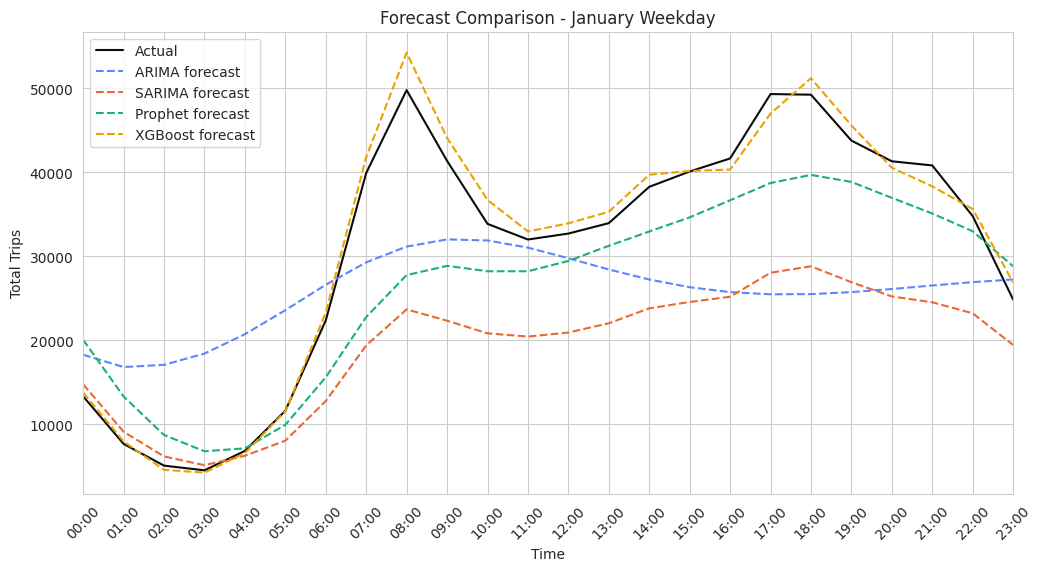

In [0]:
sns.set_style("whitegrid")

plt.figure(figsize=(12, 6))
plt.plot(comparison["index"], comparison["actual"], label="Actual", color="#0B0B0B")
plt.plot(comparison["index"], comparison["arima_forecast"], label="ARIMA forecast", linestyle="--", color="#5C85FF")
plt.plot(comparison["index"], comparison["sarima_forecast"], label="SARIMA forecast", linestyle="--", color="#eb6834")
plt.plot(comparison["index"], comparison["prophet_forecast"], label="Prophet forecast", linestyle="--", color="#1baf7a")
plt.plot(comparison["index"], comparison["xgboost_forecast"], label="XGBoost forecast", linestyle="--", color="#eda100")

plt.legend()
plt.title("Forecast Comparison - January Weekday")
plt.xlabel("Time")
plt.ylabel("Total Trips")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.xticks(rotation=45)
plt.margins(x=0)
plt.show()

The actual series shows a sharp double peak: around 50,000 trips at 8am and 49,500 trips at 5 to 6pm, with a trough overnight.

**ARIMA (log):** Produces a single soft hump around 8 to 10am, then flattens to 25,000-30,000 for the rest of the day, missing the evening rush entirely. A structural gap, not a tuning problem: plain ARIMA has no mechanism for a repeating daily cycle. MAPE 61.9%.

**SARIMA (log):** Its seasonal term (m=24) recovers a real second bump around 5 to 6pm, though still damped at roughly 29,000 against an actual of 49,500. Cuts MAPE to 33.9%, but still substantially undershoots both peaks.

**Prophet (log):** Tracks the evening rise better than ARIMA/SARIMA (reaching around 40,000 by 6pm) via its explicit weekly and yearly seasonality, but still undershoots the morning peak by a wide margin. MAPE 24.79%.

**XGBoost (recursive):** Tracks the shape of the day closely, including both peaks, but consistently runs a little hot, overshooting the morning peak by around 4,000 trips (54,000 vs 50,000 actual). MAPE 4.57%, by far the best on this window despite the local overshoot.

ARIMA and SARIMA both use the log-transformed target here since January weekday is an ordinary window where the transform helps consistently. That's not universal: for SARIMA specifically, the same transform makes New Year's Eve and Thanksgiving worse, a trade-off this window doesn't show.

### Model Forecast Comparison vs Actual (New Year's Eve)

In [0]:
arima_table = get_forecast_table("ARIMA", "new_years_eve", "log")
sarima_table = get_forecast_table("SARIMA", "new_years_eve", None)
prophet_table = get_forecast_table("Prophet", "new_years_eve", "raw")
xgboost_table = get_forecast_table("XGBoost", "new_years_eve", "recursive")

In [0]:
comparison_nye = arima_table[["index", "actual"]].copy()
comparison_nye["arima_forecast"] = arima_table["forecast"]
comparison_nye["sarima_forecast"] = sarima_table["forecast"]
comparison_nye["prophet_forecast"] = prophet_table["forecast"]
comparison_nye["xgboost_forecast"] = xgboost_table["forecast"]
comparison_nye["index"] = pd.to_datetime(comparison_nye["index"])
comparison_nye

,index,actual,arima_forecast,sarima_forecast,prophet_forecast,xgboost_forecast
0,2025-12-31 00:00:00,25572,29174.352673,24940.345582,24574.243704,24871.250000
1,2025-12-31 01:00:00,16468,26613.334134,16753.215405,17850.235980,16134.180664
2,2025-12-31 02:00:00,11352,24864.171703,11317.720934,11242.345363,9892.660156
3,2025-12-31 03:00:00,8552,23870.101231,8676.627528,6853.215784,7520.568848
4,2025-12-31 04:00:00,9181,23532.588222,9448.878058,6608.005346,8652.796875
5,2025-12-31 05:00:00,10892,23688.172855,11572.626621,10926.335745,12293.090820
6,2025-12-31 06:00:00,16812,24184.614609,18934.452498,18165.766186,19220.341797
7,2025-12-31 07:00:00,22839,24853.517436,28317.305028,25413.789841,28232.787109
8,2025-12-31 08:00:00,29988,25552.877079,36193.624530,30159.347952,35326.382812
9,2025-12-31 09:00:00,31045,26160.235899,35572.336288,31654.856260,34451.343750


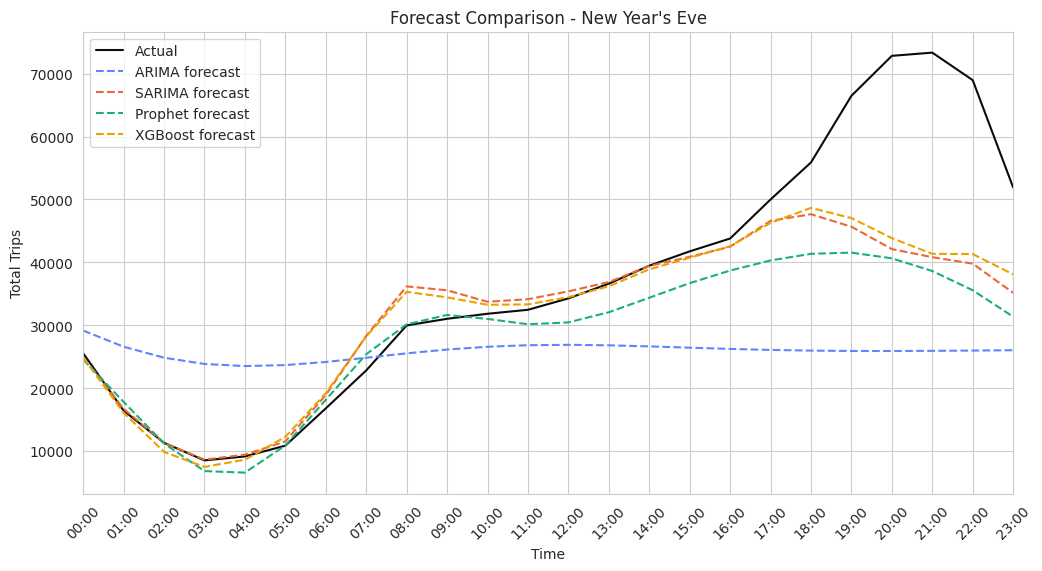

In [0]:
sns.set_style("whitegrid")

plt.figure(figsize=(12, 6))
plt.plot(comparison_nye["index"], comparison_nye["actual"], label="Actual", color="#0B0B0B")
plt.plot(comparison_nye["index"], comparison_nye["arima_forecast"], label="ARIMA forecast", linestyle="--", color="#5C85FF")
plt.plot(comparison_nye["index"], comparison_nye["sarima_forecast"], label="SARIMA forecast", linestyle="--", color="#eb6834")
plt.plot(comparison_nye["index"], comparison_nye["prophet_forecast"], label="Prophet forecast", linestyle="--", color="#1baf7a")
plt.plot(comparison_nye["index"], comparison_nye["xgboost_forecast"], label="XGBoost forecast", linestyle="--", color="#eda100")

plt.legend()
plt.title("Forecast Comparison - New Year's Eve")
plt.xlabel("Time")
plt.ylabel("Total Trips")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.xticks(rotation=45)
plt.margins(x=0)
plt.show()

Where january_weekday's actual series had a predictable double commute peak, new_years_eve's actual series does something different: a late, steep countdown surge, climbing from around 44,000 trips at 4pm to roughly 73,500 around 8-9pm, before dropping back to 52,000 by 11pm.

**ARIMA (log):** Barely responds to the surge at all, staying flat around 24,000-29,000 across the whole day, the same structural gap seen on january_weekday, no mechanism for any daily shape beyond a soft trend. MAPE 55.2%.

**SARIMA (raw):** Picks up on the rise and tracks it through the afternoon, but its own peak lands around 6pm, roughly 48,000, then it's already declining for the next two to three hours while the actual peak keeps climbing to 73,500. MAPE 13.38%, the best on this window, earned in the ordinary hours rather than the peak itself.

**Prophet (raw):** The same early-peak pattern as SARIMA, more pronounced: peaks earliest of the three responsive models and has fallen further by the time actual reaches its true peak. MAPE 17.31%.

**XGBoost (recursive):** Nearly identical shape to SARIMA, rising on schedule through the afternoon, then peaking around 6pm and declining while actual is still climbing. MAPE 13.76%, a near-tie with SARIMA, both wrong about the same few evening hours in a similar way.

None of the four models extrapolate the countdown surge far enough: ARIMA doesn't respond to it at all, and SARIMA, Prophet, and XGBoost all detect the rise starting but stop extrapolating it two to three hours too soon, missing not just the true height of the peak but its timing too.

### Best Model per Backtest Window

In [0]:
best_arima = arima_summary.min(axis=1)
best_sarima = sarima_summary.min(axis=1)
best_prophet = prophet_summary.min(axis=1)
best_xgboost = xgboost_summary["recursive"]  # not .min(), since raw is excluded on principle, not compared

model_comparison = pd.DataFrame({
    "ARIMA": best_arima,
    "SARIMA": best_sarima,
    "Prophet": best_prophet,
    "XGBoost": best_xgboost,
})

In [0]:
model_columns = ["ARIMA", "SARIMA", "Prophet", "XGBoost"]

model_comparison["best_model"] = model_comparison[model_columns].idxmin(axis=1)
model_comparison["best_mape"] = model_comparison[model_columns].min(axis=1)
model_comparison

,ARIMA,SARIMA,Prophet,XGBoost,best_model,best_mape
window,,,,,,
january_weekday,61.882353,33.947362,24.793242,4.565065,XGBoost,4.565065
january_weekend,49.150552,39.552912,21.020633,4.752404,XGBoost,4.752404
july_weekday,59.379495,27.649392,14.637560,4.521929,XGBoost,4.521929
july_weekend,35.866041,34.133290,20.376617,5.590624,XGBoost,5.590624
new_years_eve,55.224844,13.377900,17.305251,13.757276,SARIMA,13.377900
thanksgiving,49.499834,29.223527,23.956195,19.138416,XGBoost,19.138416


XGBoost (recursive) is the best model on five of six of the backtest windows, often by a wide margin: 4.5% to 19.1% MAPE against the next-best model's 14.6% to 24.8% on the same windows. SARIMA (raw) is the sole exception, winning new_years_eve narrowly, 13.38% vs XGBoost recursive's 13.76%, a 0.38pp gap. The new_years_eve chart above shows why this one is close rather than a clean win either way: the two models produce an almost identical shape there, both picking up the rise on schedule then peaking early and undershooting the true peak by a similar amount. Whatever separates them by 0.38pp isn't visible in that chart, and isn't claimed here.

### Build Model Comparison Table (for Power BI)

In [0]:
model_comparison = model_comparison.reset_index()
model_comparison_spark = spark.createDataFrame(model_comparison)
model_comparison_spark.write.format("delta").mode("overwrite").saveAsTable("model_comparison")


---------------------------------------------------------------------------
PySparkAttributeError                     Traceback (most recent call last)
File <command-8586592390062591>, line 1
----> 1 model_comparison = model_comparison.reset_index()
      2 model_comparison = spark.createDataFrame(model_comparison)
      3 model_comparison.write.format("delta").mode("overwrite").saveAsTable("model_comparison")

File /databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/dataframe.py:1770, in DataFrame.__getattr__(self, name)
   1767 # END-EDGE
   1769 if name not in self.columns:
-> 1770     raise PySparkAttributeError(
   1771         errorClass="ATTRIBUTE_NOT_SUPPORTED", messageParameters={"attr_name": name}
   1772     )
   1774 return self._col(name)

PySparkAttributeError: [ATTRIBUTE_NOT_SUPPORTED] Attribute `reset_index` is not supported.

### Build Forecast Output Table (for Power BI)

In [0]:
# make list of the windows
window_labels = []
for w in BACKTEST_WINDOWS:
    window_labels.append(w["label"])

rows = []

for window in window_labels:
    # look up each model's best-scoring variant for this window
    best_variant = {
        "ARIMA": arima_summary.loc[window].idxmin(),
        "SARIMA": sarima_summary.loc[window].idxmin(),
        "Prophet": prophet_summary.loc[window].idxmin(),
        "XGBoost": "recursive",  # always, raw is excluded on principle
    }

    actual_added = False

    for model_type, variant in best_variant.items():
        # ARIMA/SARIMA "raw" predates the transform param being logged - stored as None, not "raw"
        lookup_variant = None if model_type in ("ARIMA", "SARIMA") and variant == "raw" else variant

        table = get_forecast_table(model_type, window, lookup_variant)
        table = table.rename(columns={"index": "hour"})
        table["hour"] = pd.to_datetime(table["hour"])

        if not actual_added:
            actual_rows = table[["hour", "actual"]].rename(columns={"actual": "value"})
            actual_rows["window"] = window
            actual_rows["model"] = "Actual"
            rows.append(actual_rows)
            actual_added = True

        forecast_rows = table[["hour", "forecast"]].rename(columns={"forecast": "value"})
        forecast_rows["window"] = window
        forecast_rows["model"] = model_type
        rows.append(forecast_rows)

forecast_output = pd.concat(rows, ignore_index=True)[["window", "hour", "model", "value"]]
forecast_output

,window,hour,model,value
0,january_weekday,2025-01-14 00:00:00,Actual,13350.000000
1,january_weekday,2025-01-14 01:00:00,Actual,7688.000000
2,january_weekday,2025-01-14 02:00:00,Actual,5100.000000
3,january_weekday,2025-01-14 03:00:00,Actual,4543.000000
4,january_weekday,2025-01-14 04:00:00,Actual,6852.000000
...,...,...,...,...
715,new_years_eve,2025-12-31 19:00:00,XGBoost,47041.945312
716,new_years_eve,2025-12-31 20:00:00,XGBoost,43856.152344
717,new_years_eve,2025-12-31 21:00:00,XGBoost,41367.179688
718,new_years_eve,2025-12-31 22:00:00,XGBoost,41328.503906


In [0]:
forecast_output_spark = spark.createDataFrame(forecast_output)
forecast_output_spark.write.format("delta").mode("overwrite").saveAsTable("forecast_output")